This notebook contains code to load the ML6 dataset and peform feature selection using splitted traning and testing dataset.
- Train the model without normalization

In [1]:
import sys
sys.path.insert(0, '../')

In [2]:
import warnings
warnings.filterwarnings('ignore')

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from sklearn.base import clone

# load local variables
from src.config import *
from src.load_models import select_model
from src.utils import calculate_r2_score, calculate_per_diff, calculate_combined_r2_and_per_diff, per_error, find_adj_score, combine_all_batches, split_batches_back, perform_combat_normalization
from src.feature_selection import ModelSelection
from src.graph_visualization import feature_selection_tabularize


In [3]:
# Load Extracted features dataset
ML6_1 = pd.read_excel('/Users/sangam/Desktop/Epilepsey/Code/vgramreg/dataset/ML6/Day 1 Data/feature_extraction_noise_None.xlsx')
ML6_2 = pd.read_excel('/Users/sangam/Desktop/Epilepsey/Code/vgramreg/dataset/ML6/Day 2 Data/feature_extraction_noise_None.xlsx')

ML6_2['label'] = ML6_2['file'].apply(lambda x: x.split('/')[-1].split('_')[-2].replace('cbz','')).apply(lambda x: int(x))
ML6_2 = ML6_2.drop(columns='file')

ML6_1['label'] = ML6_1['file'].apply(lambda x: x.split('/')[-1].split('_')[-2].replace('cbz','')).apply(lambda x: int(x))
ML6_1 = ML6_1.drop(columns='file')

In [4]:
ML6_1['dataset_name'] = '1'
ML6_2['dataset_name'] = '2'

final_dataset = pd.concat([ML6_1, ML6_2], ignore_index=True)

In [5]:
final_dataset.rename(columns={"PH": 'max(S)', 'signal_std':'std(S)', 'signal_mean':'mean(S)', 'peak area':'area(S)', \
                        'dS_dV_area':'area(dS/dV)', 'dS_dV_max_peak':'max(dS/dV)', 'dS_dV_min_peak':'min(dS/dV)',\
                    'dS_dV_peak_diff':'max(dS/dV) - min(dS/dV)', \
                    'peak V':'V_max(S)', 'dS_dV_max_V':'V_max(dS/dV)', 'dS_dV_min_V':'V_min(dS/dV)',\
        }, inplace = True)

In [6]:
final_dataset

,area(S),peak curvature,V_max(S),vcenter,max(S),mean(S),std(S),max(dS/dV),min(dS/dV),max(dS/dV) - min(dS/dV),V_max(dS/dV),V_min(dS/dV),area(dS/dV),f1,f2,label,dataset_name
0,1.1035,24.6339,1.0509,1.0463,0.017510,0.0016,0.0042,0.3809,-0.5244,0.9053,1.032,1.080,0.0350,0.7072,-16.8102,4,1
1,2.2940,39.5391,1.0582,1.0480,0.033824,0.0033,0.0084,0.6989,-0.8795,1.5785,1.036,1.092,0.0676,1.3894,34.8073,4,1
2,3.1824,69.2021,1.0461,1.0538,0.051996,0.0045,0.0123,1.2167,-1.4382,2.6549,1.016,1.072,0.1040,1.5455,34.8061,8,1
3,3.1574,99.2381,1.0484,1.0491,0.054249,0.0045,0.0126,1.2173,-1.6441,2.8614,1.020,1.076,0.1085,1.0457,-4.3396,8,1
4,5.5264,131.3698,1.0657,1.0712,0.090447,0.0079,0.0215,2.1041,-2.5004,4.6045,1.036,1.092,0.1809,1.2007,25.1452,16,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,8.8870,186.6420,1.0594,1.0619,0.136665,0.0127,0.0331,2.9070,-3.4862,6.3932,1.028,1.088,0.2733,1.4306,44.7135,16,2
221,2.0187,46.4979,1.0517,1.0510,0.031516,0.0029,0.0076,0.6744,-0.8230,1.4974,1.020,1.076,0.0630,1.1217,14.4177,8,2
222,4.3946,91.3094,1.0545,1.0570,0.065702,0.0063,0.0161,1.3993,-1.5154,2.9146,1.016,1.084,0.1314,0.9395,35.8728,12,2
223,1.8908,18.8623,1.0352,1.0270,0.024186,0.0027,0.0064,0.5026,-0.6235,1.1261,1.016,1.076,0.0484,0.7506,-3.4662,4,2


Text(0.5, 1.0, 'Box Plot for ML6 1 and 2 datset')

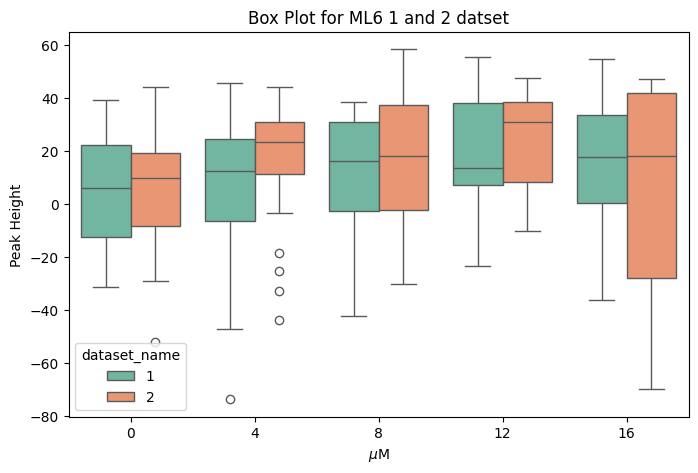

In [7]:
label_order = [0, 4, 8, 12, 16]
plt.figure(figsize=(8, 5))
sns.boxplot(x="label", y="f2", data=final_dataset, hue="dataset_name", palette="Set2", order=label_order)

# Customize the plot
plt.xlabel(r"$\mu $M")
plt.ylabel("Peak Height")
plt.title("Box Plot for ML6 1 and 2 datset")

In [8]:
Y           = final_dataset['label']
X           = final_dataset.drop(columns=['label', 'dataset_name'])

X_train, X_test, y_train, y_test  = train_test_split(X, Y, test_size=0.4, shuffle=True, random_state=42, stratify=Y)

In [9]:
# List of models
models = ['Linear', 'KNN', 'SVM', 'RF', 'GP']

# Calcualte y_LOD
y_LOD     = 0.9117010154341669 #calculate_y_LOD(X_testing, y_testing)
kf        = KFold(n_splits=5, shuffle=True, random_state=42)
add_alpha = False

find_class_stratified_score = True

r2_score_val,  per_diff_val  = {'Models':[], 'Scores':[]}, {'Models':[], 'Scores':[]}
r2_score_test, per_diff_test = {'Models':[], 'Scores':[]}, {'Models':[], 'Scores':[]}

r2_score_class_stratified_test = {'Models':[], '0':[], '5':[], '8':[], '10':[], '15':[], '16':[]} if add_alpha else {'Models':[], '0':[], '8':[], '16':[]}
per_diff_class_stratified_test = {'Models':[], '0':[], '5':[], '8':[], '10':[], '15':[], '16':[]} if add_alpha else {'Models':[], '0':[], '8':[], '16':[]}

metric  = 'per_diff'
for model_name in models:
   
    model             = ModelSelection(model_name, X_train, y_train)
    selected_features = model.find_best_features(kf, metric=metric, use_adjusted_r2=True)
    df = feature_selection_tabularize(selected_features)

    df.to_excel(f'../results/Journal_paper/Feature_selection/{model_name}_feature_selection_{metric}.xlsx')
    # print(f"Model Names: {model_name}")
    # print(f"Selected features: {selected_features}")
    

In [ ]:
df

In [ ]:
r2        = calculate_r2_score(model.model, X_train, y_train, kf)
per_diff  = calculate_per_diff(model.model, X_train, y_train, kf, y_LOD)

combined  = calculate_combined_r2_and_per_diff(model.model, X_train, y_train, kf, y_LOD, use_adjusted_r2=True)
r2, per_diff, combined

In [ ]:
model.model

In [ ]:
np.array(a).dtype